In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
from sklearn import datasets, tree 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, ConfusionMatrixDisplay 
# Load Iris dataset (built into scikit-learn, no upload needed) 
iris = datasets.load_iris(as_frame=True) 
iris_df = iris.frame 
iris_df['Species'] = iris_df['target'].map(dict(enumerate(iris.target_names))) 
iris_df = iris_df.drop(columns=['target']) 
print(iris_df.head()) 

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [2]:
print(iris_df.isnull().any())

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
Species              False
dtype: bool


In [3]:
print(iris_df.describe()) 

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


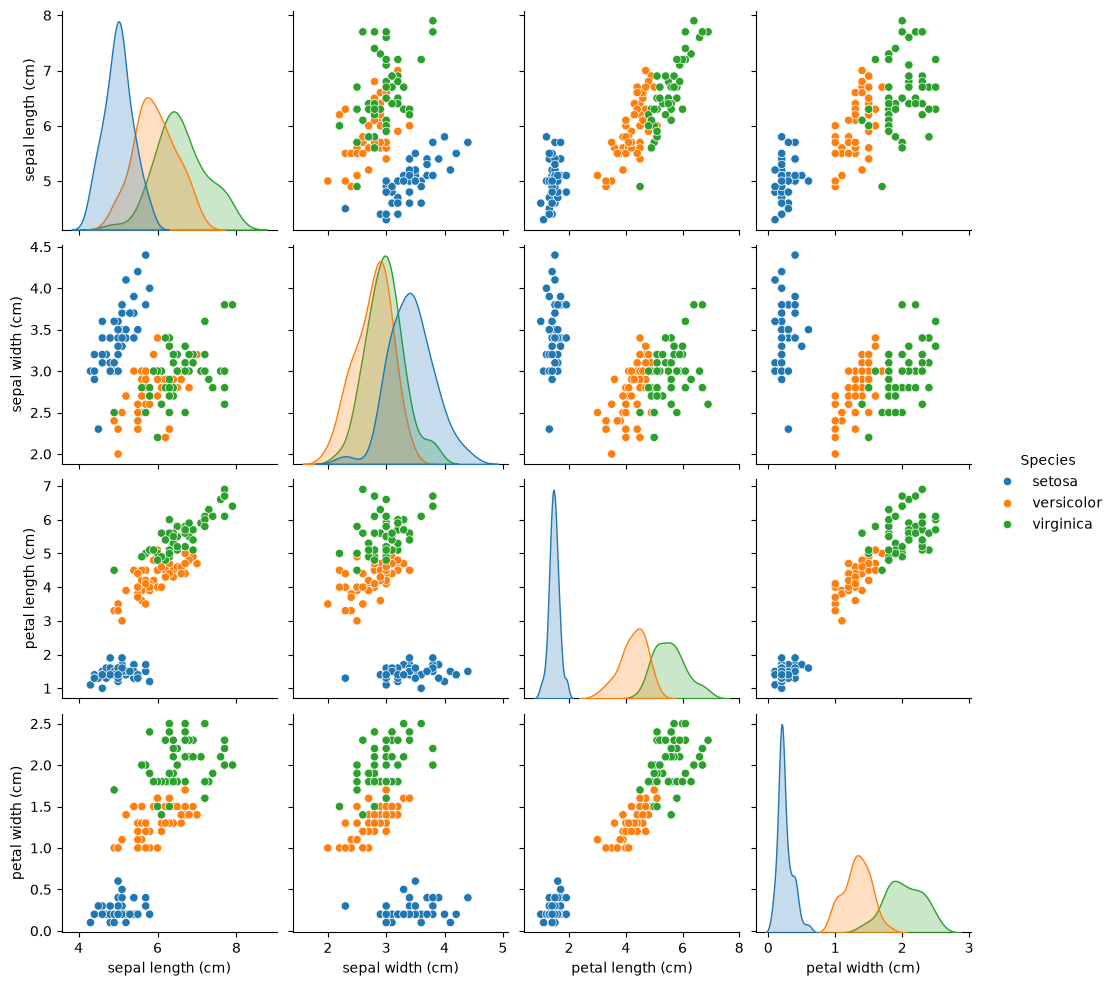

In [4]:
# Pair plot to view feature relationships 
sns.pairplot(iris_df, hue='Species')


In [5]:
# Split into train and test sets 
X = iris.data.values 
y = iris_df['Species'].values 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=1) 
# Train the decision tree classifier 
clf = tree.DecisionTreeClassifier(random_state=1) 
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [6]:
# Test the trained model 
prediction = clf.predict(X_test) 
print(prediction)

[np.str_('setosa') np.str_('versicolor') np.str_('versicolor')
 np.str_('setosa') np.str_('virginica') np.str_('versicolor')
 np.str_('virginica') np.str_('setosa') np.str_('setosa')
 np.str_('virginica') np.str_('versicolor') np.str_('setosa')
 np.str_('virginica') np.str_('versicolor') np.str_('versicolor')]


In [7]:
# Evaluate on test set 
print(classification_report(y_test, prediction)) 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



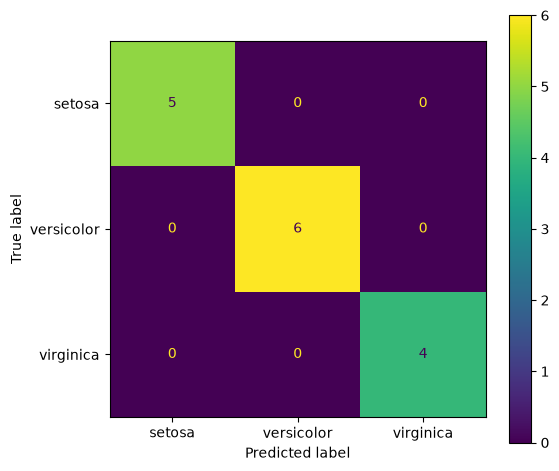

In [8]:
# Plot confusion matrix 
fig, ax = plt.subplots(figsize=(6, 5)) 
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, ax=ax, colorbar=True) 
plt.tight_layout() 
plt.savefig("ex1_confmatrix.png") 

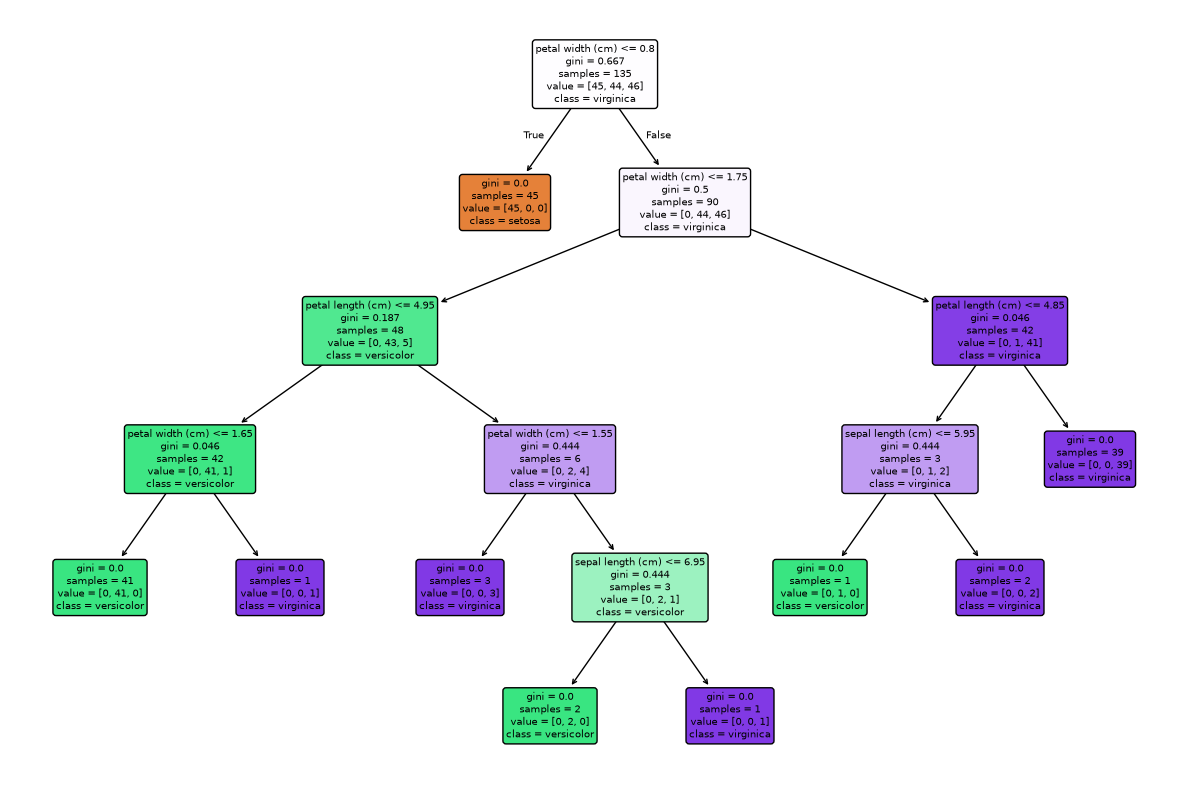

In [9]:
# Visualize the decision tree 
fig, ax = plt.subplots(figsize=(12, 8)) 
tree.plot_tree(clf, feature_names=iris.feature_names, 
class_names=iris.target_names, filled=True, rounded=True, ax=ax) 
plt.tight_layout() 
plt.savefig("ex1_tree.png") 

In [11]:
# Feed new data to the classifier to predict the class 
sample = [[4.8, 2.9, 1.3, 0.2]]   # SepalLengthCm, SepalWidthCm, PetalLengthCm, 
res = clf.predict(sample) 
print("The class predicted is --> " + str(res[0])) 

The class predicted is --> setosa
